In [1]:
import sys
sys.path.append('..')
from osp import *

In [2]:
df_meta = get_corpus_metadata()

In [3]:
def get_df_probs(df_preds):
    l = []
    for i,r in df_preds.iterrows():
        x1,x2 = r['comparison'].split(' vs ')
        prob1 = r['prob_'+x1]
        prob2 = r['prob_'+x2]
        l.append(
            {
                'comparison':r['comparison'], 
                'id':r['id'], 
                'prob1':prob1, 
                'prob2':prob2, 
                'pred':x1 if prob1>prob2 else x2,
            }
        )
    return pd.DataFrame(l)


In [32]:
df_preds = pd.read_pickle('../data/raw/df_preds3.pkl.gz')
odfx = df_preds.query('predict_type!="cv"').reset_index().groupby(['comparison','id']).mean(numeric_only=True).reset_index()
df_probs = get_df_probs(odfx)

In [33]:
# df_probs.journal.value_counts()

In [5]:
for c,cdf in df_preds.groupby(['comparison','run']):
    break

In [6]:
# cdf

In [15]:
# df_probs = pd.read_pickle('../data/raw/df_probs3.pkl.gz')
id2disc = dict(zip(df_meta.index, df_meta['discipline']))
id2dec = dict(zip(df_meta.index, df_meta['decade']))
id2year = dict(zip(df_meta.index, df_meta['year']))
id2period = dict(zip(df_meta.index, df_meta['period']))
df_probs['true'] = df_probs['id'].apply(lambda x: id2disc[x.split('__')[0]])
df_probs['discipline'] = df_probs['id'].apply(lambda x: id2disc[x.split('__')[0]])
df_probs['period'] = df_probs['id'].apply(lambda x: id2period[x.split('__')[0]])
df_probs['pred'] = df_probs['pred'].apply(lambda x: x.split()[-1])
df_probs['irrelev'] = [x not in y for x,y in zip(df_probs['true'], df_probs['comparison'])]
df_probs['same_group'] = [x.split()[1] == x.split()[-1] for x in df_probs['comparison']]
df_probs['same_period'] = [x.split()[0] == x.split()[-2] for x in df_probs['comparison']]
df_probs['correct'] = df_probs['pred'] == df_probs['true']
df_probs['redundant'] = [x.split(' vs ')[0] > x.split(' vs ')[1] for x in df_probs['comparison']]
df_probs['decade'] = df_probs['id'].apply(lambda x: id2dec[x.split('__')[0]])
df_probs['year'] = df_probs['id'].apply(lambda x: id2year[x.split('__')[0]])
df_probs['predict_type'] = 'unseen'
df_probs['period_model'] = df_probs['comparison'].apply(lambda x: x.split()[0])
# df_probs = df_probs[df_probs.period_model>="1925"]
# df_probs = df_probs[~df_probs.irrelev]
df_probs = df_probs[~df_probs.same_group]
df_probs = df_probs[df_probs.same_period]
# df_probs = df_probs[~df_probs.redundant]
df_probs = df_probs[df_probs.comparison.str.contains('Philosophy')]
# df_probs = df_probs[df_probs.comparison.str.contains('Other')]
df_probs.columns

Index(['comparison', 'id', 'prob1', 'prob2', 'pred', 'true', 'discipline',
       'period', 'irrelev', 'same_group', 'same_period', 'correct',
       'redundant', 'decade', 'year', 'predict_type', 'period_model'],
      dtype='object')

In [16]:
# df_probs[df_probs.discipline=="Other"]

In [18]:
figdf = get_avgs_df(df_probs,['year','predict_type','discipline','period_model'],y='prob1').reset_index()
figdf['discipline'] = pd.Categorical(figdf['discipline'], categories=['Philosophy','Other','Literature'])
figdf['mean']*=100

In [19]:
avgdf2 = get_avgs_df(df_probs,['discipline','comparison','period_model','period'],y='prob1').reset_index()
avgdf2 = avgdf2[avgdf2.period_model == avgdf2.period]
avgdf2 = avgdf2[avgdf2.discipline=="Philosophy"]
avgdf2

,discipline,comparison,period_model,period,mean,stderr,count
1,Philosophy,2000-2025 Philosophy vs 2000-2025 Literature,2000-2025,2000-2025,0.897657,0.002130,9654
6,Philosophy,1925-1950 Philosophy vs 1925-1950 Literature,1925-1950,1925-1950,0.867958,0.004570,2246
7,Philosophy,1925-1950 Philosophy vs 1925-1950 Other,1925-1950,1925-1950,0.866503,0.004258,2246
9,Philosophy,1950-1975 Philosophy vs 1950-1975 Literature,1950-1975,1950-1975,0.851325,0.003915,3378
11,Philosophy,1975-2000 Philosophy vs 1975-2000 Literature,1975-2000,1975-2000,0.850795,0.003053,5737
12,Philosophy,1900-1925 Philosophy vs 1900-1925 Other,1900-1925,1900-1925,0.847543,0.005926,1377
16,Philosophy,1900-1925 Philosophy vs 1900-1925 Literature,1900-1925,1900-1925,0.834813,0.005819,1377
17,Philosophy,2000-2025 Philosophy vs 2000-2025 Other,2000-2025,2000-2025,0.831692,0.002303,9654
21,Philosophy,1975-2000 Philosophy vs 1975-2000 Other,1975-2000,1975-2000,0.826372,0.002855,5737
23,Philosophy,1950-1975 Philosophy vs 1950-1975 Other,1950-1975,1950-1975,0.823645,0.003971,3378


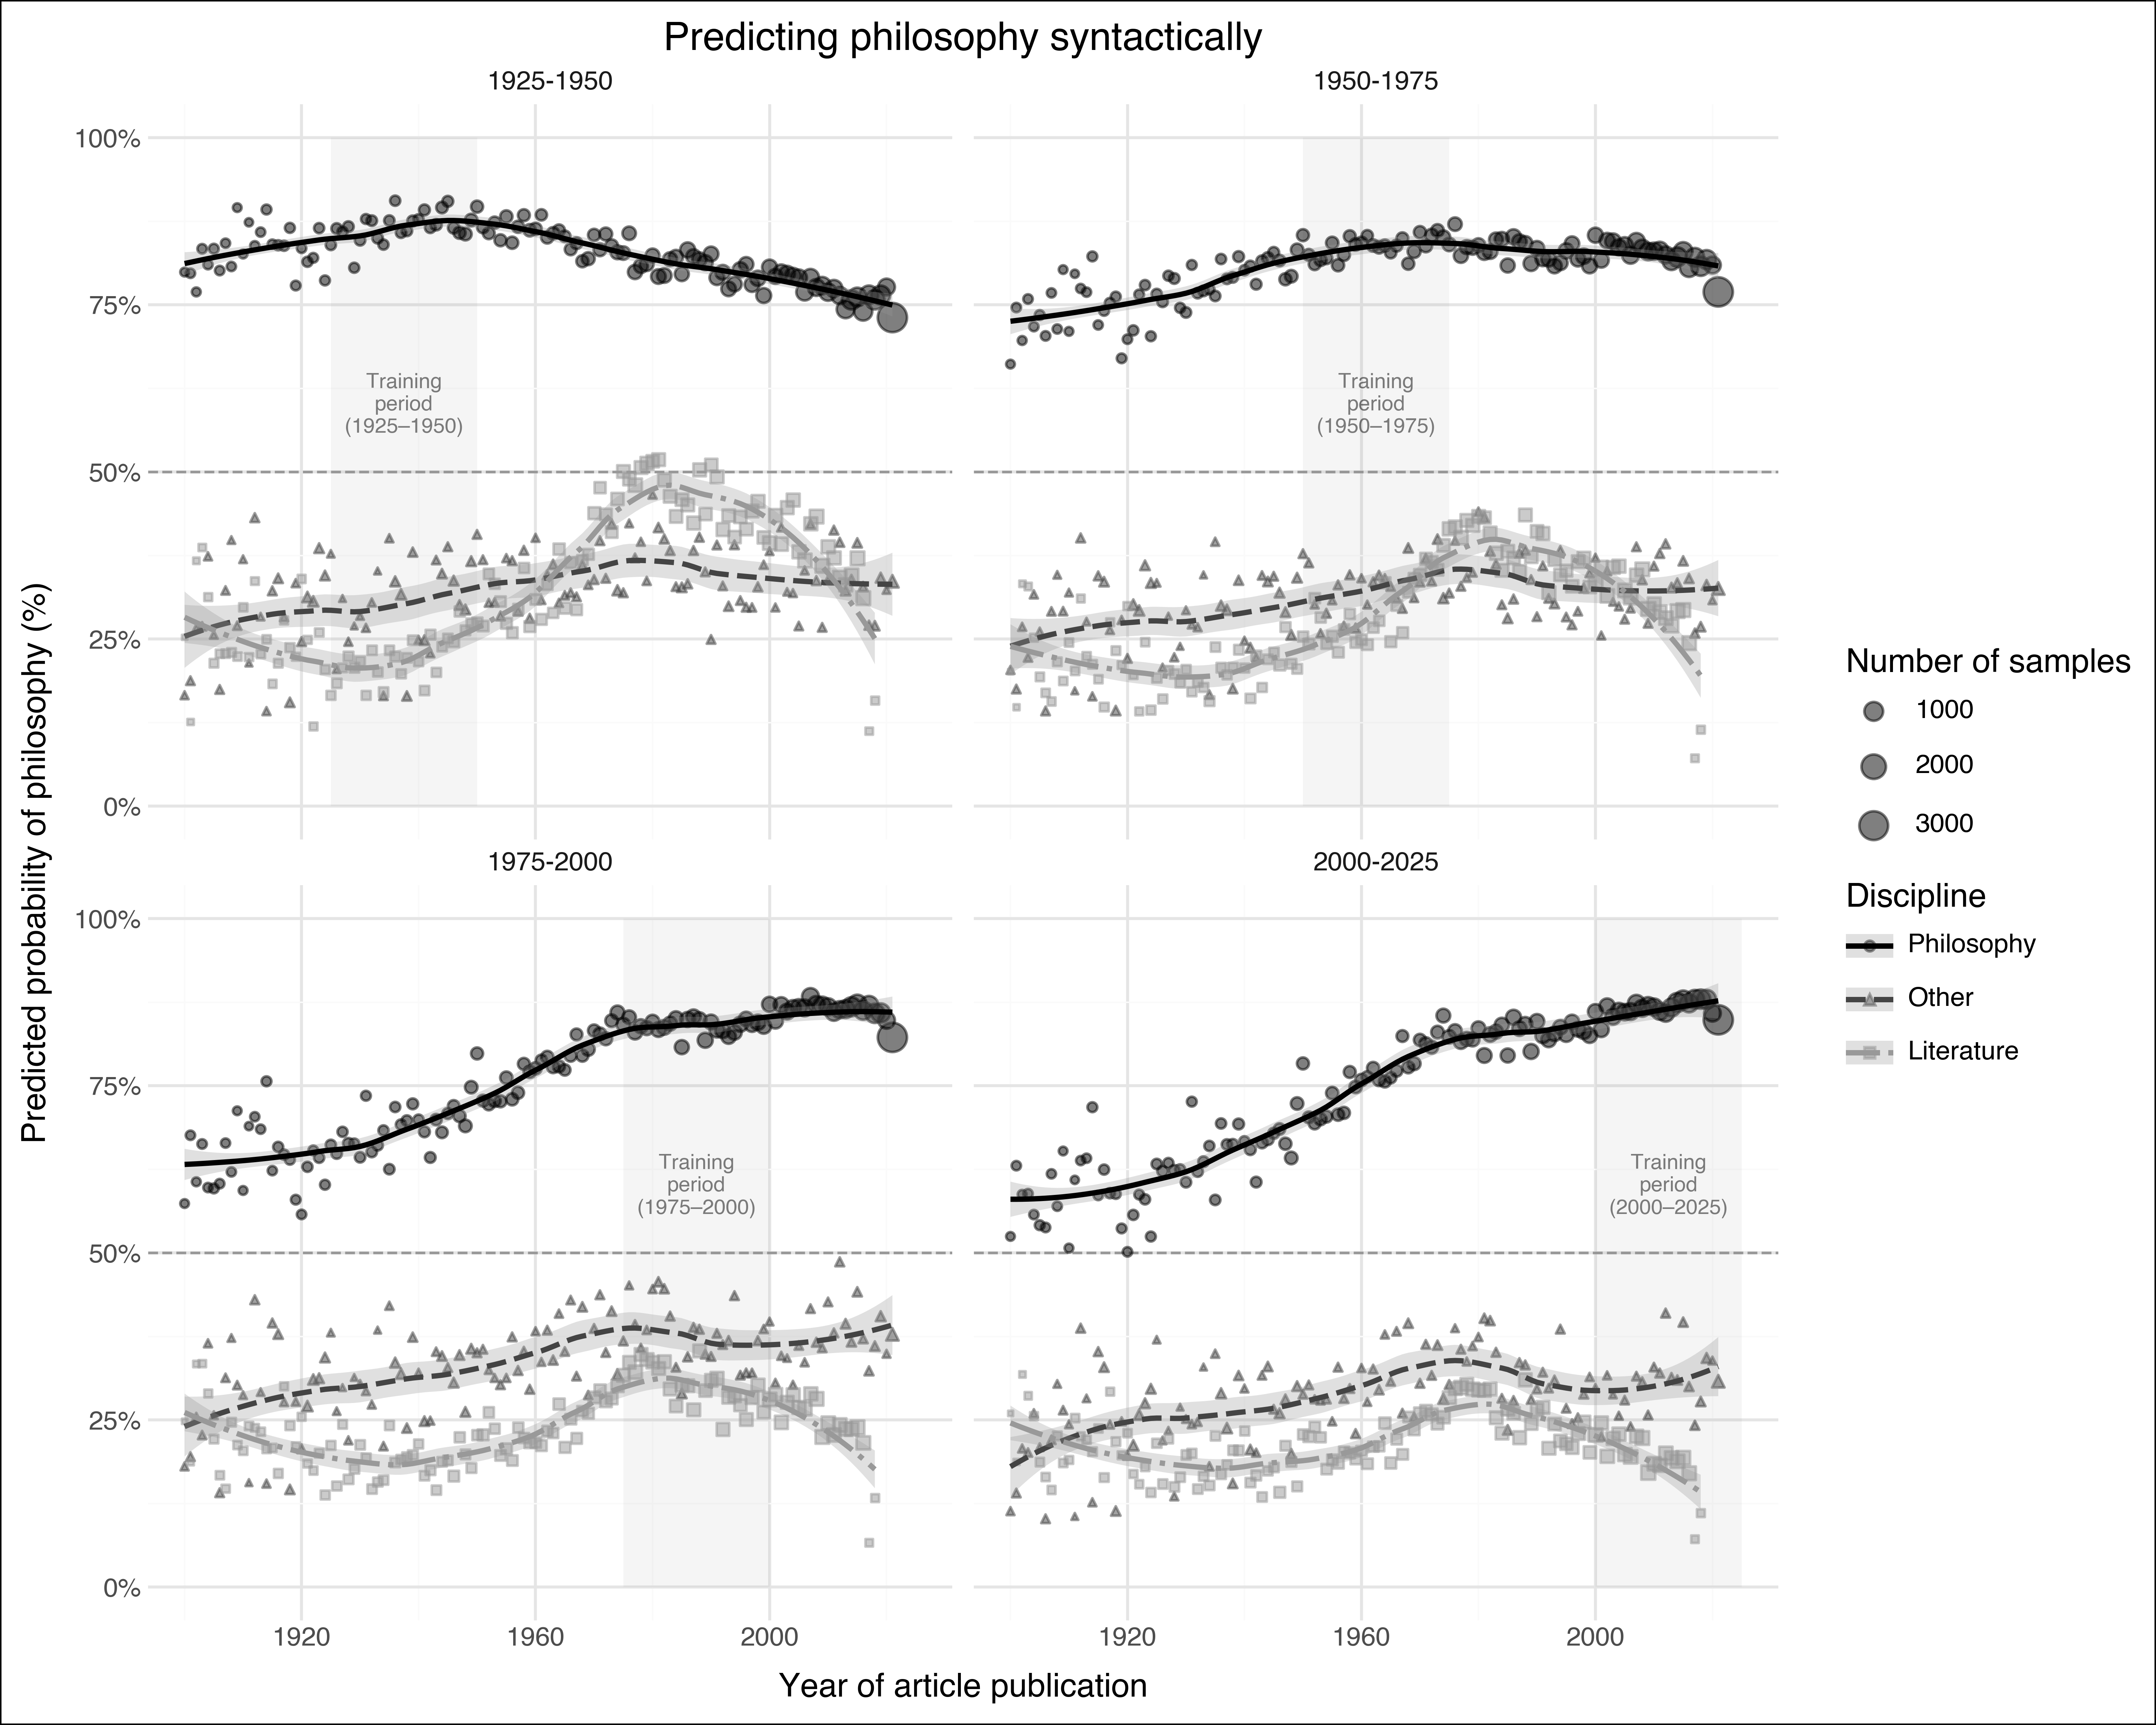

In [31]:
def plot_preds(figdf, facet_col='comparison', **labs):
    band_defs = pd.DataFrame([
        dict(period_model='1925-1950', xmin=1925, xmax=1950, label='Training\nperiod\n(1925–1950)'),
        dict(period_model='1950-1975', xmin=1950, xmax=1975, label='Training\nperiod\n(1950–1975)'),
        dict(period_model='1975-2000', xmin=1975, xmax=2000, label='Training\nperiod\n(1975–2000)'),
        dict(period_model='2000-2025', xmin=2000, xmax=2025, label='Training\nperiod\n(2000–2025)'),
    ])
    band_defs['ymin'] = 0
    band_defs['ymax'] = 100

    fig = (
        p9.ggplot(
            figdf,
            p9.aes(x='year', y='mean', color='discipline'),
        )
        + p9.geom_hline(yintercept=50, color='gray', linetype='dashed',size=.5,alpha=0.75)
        + p9.geom_rect(
            p9.aes(xmin='xmin', xmax='xmax', ymin='ymin', ymax='ymax'),
            data=band_defs,
            inherit_aes=False,
            fill='gray',
            alpha=0.075,
        )
        + p9.geom_text(
            p9.aes(x='xmin + (xmax-xmin)/2', y=60, label='label'),
            data=band_defs,
            inherit_aes=False,
            alpha=.5,
            # ha='left',
            size=7,
        )
        # + p9.geom_errorbar(p9.aes(ymin='mean-stderr', ymax='mean+stderr'), width=1, alpha=0.75)
        + p9.geom_point(p9.aes(y='mean',size='count',shape='discipline'), alpha=0.5)
        + p9.facet_wrap(facet_col)
        + p9.theme_minimal()
        + p9.scale_size_continuous(range=(.5, 5))
        + p9.scale_y_continuous(labels=lambda l: [f'{int(v)}%' for v in l])
        + p9.geom_smooth(p9.aes(linetype='discipline'), method='loess', span=0.5, alpha=0.3, size=1)
        + p9.scale_color_manual(
            values={
                'Philosophy': '#000000',   # black
                'Other': '#444444',        # slightly darker gray
                'Literature': '#999999',   # slightly darker silver
            }
        )
        + p9.labs(**labs)
        + p9.theme(
            plot_background=p9.element_rect(fill='white'),
            # plot_title=p9.element_text(ha='left',size=13),
            plot_subtitle=p9.element_text(ha='left',size=11),
        )
    )
    return fig


fig = plot_preds(
    figdf.query('period_model>="1925"'), 
    facet_col='period_model', 
    title='Predicting philosophy syntactically', 
    y="Predicted probability of philosophy (%)",
    x="Year of article publication",
    # subtitle="Predicting philosophy by quarter-century models",
    size='Number of samples',
    shape='Discipline',
    color='Discipline',
    linetype='Discipline',
)
fig.save('../figures/preds_by_period5.png')
fig

In [12]:
figdf = get_avgs_df(df_probs, ['decade', 'true', 'comparison'], 'correct').reset_index().query('count>100')
figdf

,decade,true,comparison,mean,stderr,count
0,2020,Philosophy,1975-2000 Philosophy vs 1975-2000 Literature,0.964361,0.004245,1908
1,2020,Other,1925-1950 Philosophy vs 1925-1950 Other,0.954545,0.015746,176
2,2020,Philosophy,2000-2025 Philosophy vs 2000-2025 Literature,0.952830,0.004855,1908
3,2010,Philosophy,1975-2000 Philosophy vs 1975-2000 Literature,0.951080,0.003202,4538
4,1960,Literature,2000-2025 Philosophy vs 2000-2025 Literature,0.950000,0.007524,840
...,...,...,...,...,...,...
375,1990,Literature,1975-2000 Philosophy vs 1975-2000 Other,0.000000,0.000000,1474
376,1930,Literature,1900-1925 Philosophy vs 1900-1925 Other,0.000000,0.000000,524
377,1990,Literature,1950-1975 Philosophy vs 1950-1975 Other,0.000000,0.000000,1474
378,1990,Literature,1925-1950 Philosophy vs 1925-1950 Other,0.000000,0.000000,1474


In [13]:
fig = (
    p9.ggplot(
        figdf,
        p9.aes(x='decade', y='mean',color='true')
    )
    + p9.geom_line()
    + p9.geom_errorbar(p9.aes(ymin='mean-stderr', ymax='mean+stderr'), width=0.2)
    + p9.facet_wrap('~comparison', ncol=4)
    + p9.theme_minimal()
    + p9.theme(figure_size=(15, 12))
    + p9.scale_y_continuous(limits=(.5,1))
)
fig